In [ ]:
!pip install pandas pyspark matplotlib numpy

In [ ]:
!pip install pypdf langchain langchain-community chromadb openai sentence-transformers matplotlib numpy

#Part 0: Data Ingestion and Transformation

In [ ]:
import requests
import os
from pathlib import Path
import pandas as pd
import time

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

Taxi data

In [ ]:
def get_taxi_data():
  down_dir = Path("data/raw")
  down_dir.mkdir(parents=True, exist_ok=True)

  download = [
    {
        'url': 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet',
        'filename': down_dir / 'yellow_tripdata_2024-01.parquet'
    }
  ]

  for file in download:
    print(f'Downloading {file['url']}...')

    response = requests.get(file['url'], stream=True)

    response.raise_for_status()

    with open(file['filename'], 'wb') as f:
      for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

    print(f'Downloaded to {file['filename']}')

get_taxi_data()

Downloaded to data/raw/yellow_tripdata_2024-01.parquet


#Part 1: Distributed Data Processing with Spark

## Task 1.1: Spark Environment Setup & Data Loading

* Create a SparkSession with appropriate config (app name, memory settings, adaptive query execution)

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
  .master('local[*]') \
  .appName('COMP3610_Assignment3') \
  .config('spark.sql.adaptive.enabled', 'true') \
  .config('spark.driver.memory', '4g') \
  .getOrCreate()

# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Spark version: 4.0.2
App name: COMP3610_Assignment3
Master: local[*]
Default parallelism: 2


* Load the NYC Yellow Taxi Parquet data into a Spark  DataFrame

In [ ]:
start = time.time()
taxi_df = spark.read.parquet(f'data/raw/yellow_tripdata_2024-01.parquet')
spark_read_time = time.time() - start #Compare load time against Pandas for the same file

* Display the schema and verify column types

In [ ]:
taxi_df.printSchema

<bound method DataFrame.printSchema of DataFrame[VendorID: int, tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, passenger_count: bigint, trip_distance: double, RatecodeID: bigint, store_and_fwd_flag: string, PULocationID: int, DOLocationID: int, payment_type: bigint, fare_amount: double, extra: double, mta_tax: double, tip_amount: double, tolls_amount: double, improvement_surcharge: double, total_amount: double, congestion_surcharge: double, Airport_fee: double]>

* Report the total row count and DataFrame partition count

In [ ]:
print(f'Number of rows: {taxi_df.count():,}')
print(f'Number of columns: {len(taxi_df.columns)}')
print(f'Number of partitions: {taxi_df.rdd.getNumPartitions()}')

Number of rows: 2,964,624
Number of columns: 19
Number of partitions: 2


* Compare load time against Pandas for the same file (use time measurement)

In [ ]:
start = time.time()
spark_count = taxi_df.count()
spark_count_time = time.time() - start

start = time.time()
pandas_df = pd.read_parquet(f'data/raw/yellow_tripdata_2024-01.parquet')
pandas_read_time = time.time() - start

total_spark_time = spark_read_time + spark_count_time

print(f'Spark schema read: {spark_read_time:.3f}s (lazy - no data loaded)')
print(f'Spark count action: {spark_count_time:.3f}s ({spark_count:,} rows)')
# print(f'Spark full read: {total_spark_time: .3f}s')
print(f'Pandas full read: {pandas_read_time:.3f}s ({len(pandas_df):,} rows)')

del pandas_df

Spark schema read: 0.150s (lazy - no data loaded)
Spark count action: 0.424s (2,964,624 rows)
Pandas full read: 1.032s (2,964,624 rows)


The time with is taken by Spark to load the file is significantly quicker than loading the data with pandas. It should be noted that since loading data with spark is lazy, it doesn't load data, until an action is called.

##Task 1.2: Data Cleaning & Feature Engineering in Spark

* Remove rows with null values in critical columns (pickup/dropoff times, locations, fare,
distance)

In [ ]:
from pyspark.sql import functions as F

trips = taxi_df.select(
  F.col('tpep_pickup_datetime').alias('pickup_time'),
  F.col('tpep_dropoff_datetime').alias('dropoff_time'),
  'passenger_count',
  'trip_distance',
  'fare_amount',
  'tip_amount',
  'total_amount',
  'payment_type',
  'PULocationID',
  'DOLocationID'
)

trips = trips.dropna(subset=[
    'pickup_time',
    'dropoff_time',
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'payment_type',
    'PULocationID',
    'DOLocationID'
])

#count of rows removed at each cleaning step
before = taxi_df.count()
after = trips.count()
rows_removed = before - after

print(f'Number of rows removed: {rows_removed:,}')
print(f'Number of rows remaining: {after:,}')

Number of rows removed: 140,162
Number of rows remaining: 2,824,462


* Filter out invalid trips

In [ ]:
before = trips.count()

trips = trips.filter(
    (F.col('trip_distance') > 0) & #zero/negative distance
    (F.col('fare_amount') > 0) & # negative fares
    (F.col('fare_amount') <= 500) & #high fare exceeding $500
    (F.col('pickup_time') < F.col('dropoff_time')) #dropoff before pickup
)

#count of rows removed at each cleaning step
after = trips.count()
rows_removed = before - after

print(f'Number of rows removed: {rows_removed:,}')
print(f'Number of rows remaining: {after:,}')

Number of rows removed: 70,085
Number of rows remaining: 2,754,377


* Derived columns using Spark functions

In [ ]:
trips = trips.withColumns({
    'trip_duration_minutes': (F.unix_timestamp('dropoff_time') - F.unix_timestamp('pickup_time')) / 60,
    'trip_speed_mph': F.when(F.col('trip_duration_minutes') > 0, (F.col('trip_distance') / (F.col('trip_duration_minutes')) * 60)).otherwise(0),
    'pickup_hour' : F.hour('pickup_time'), #pickup_hour (0–23)
    'pickup_day_of_week' : F.dayofweek('pickup_time'), #pickup_day_of_week (1=Sunday to 7=Saturday)
    'tip_percentage': (F.col('tip_amount') / F.col('fare_amount') * 100)
})

trips.show(5)

+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+---------------------+------------------+-----------+------------------+------------------+
|        pickup_time|       dropoff_time|passenger_count|trip_distance|fare_amount|tip_amount|total_amount|payment_type|PULocationID|DOLocationID|trip_duration_minutes|    trip_speed_mph|pickup_hour|pickup_day_of_week|    tip_percentage|
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+---------------------+------------------+-----------+------------------+------------------+
|2024-01-01 00:57:55|2024-01-01 01:17:43|              1|         1.72|       17.7|       0.0|        22.7|           2|         186|          79|                 19.8| 5.212121212121212|          0|                 2|               0.0|
|2024-01-01 00:03:00|2024-01-01 00:09:36|       

##Task 1.3: Spark SQL Analytics

**Query 1:** What are the top 10 busiest pickup hours, and what is the average fare and tip
percentage for each?

In [ ]:
trips.createOrReplaceTempView('trips')

busiest_hour = spark.sql('''
    SELECT pickup_hour,
        COUNT(*) as num_trips,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(AVG(tip_percentage), 2) as avg_tip_percentage
    FROM trips
    GROUP BY pickup_hour
    ORDER BY num_trips DESC
    LIMIT 10
''')

print('Top 10 busiest pickup hours:')
busiest_hour.show()

Top 10 busiest pickup hours:
+-----------+---------+--------+------------------+
|pickup_hour|num_trips|avg_fare|avg_tip_percentage|
+-----------+---------+--------+------------------+
|         18|   198009|   16.93|             23.35|
|         17|   193361|   18.04|             22.78|
|         16|   180356|    19.4|             22.05|
|         15|   179043|   19.04|             20.02|
|         14|   173418|    19.2|             20.01|
|         19|   172393|   17.61|             23.37|
|         13|   161129|   18.36|             19.96|
|         12|   155425|   17.75|             19.95|
|         20|   150678|   18.06|             22.57|
|         21|   149766|   18.33|             22.45|
+-----------+---------+--------+------------------+



The most top 5 most popular pickup hours can be associated with when a mojority of people would be getting off from school or work. It can alosi be seen that the top 10's average fares range from 16.93 dollars to 19.40 dollars and the tip percentages for all the hours being relatively close ranging from 19.95% to 23.35%

**Query 2:** Which day of the week has the highest average trip speed? Include average
distance and duration.

In [ ]:
high_avg_trip_speed = spark.sql('''
    SELECT pickup_day_of_week,
        COUNT(*) as num_trips,
        ROUND(AVG(trip_speed_mph), 2) as avg_trip_speed,
        ROUND(AVG(trip_distance), 2) as avg_distance,
        ROUND(AVG(trip_duration_minutes), 2) as avg_duration_mins
    FROM trips
    GROUP BY pickup_day_of_week
    ORDER BY avg_trip_speed DESC
''')

print('Average trip speed by day of week:')
high_avg_trip_speed.show()

Average trip speed by day of week:
+------------------+---------+--------------+------------+-----------------+
|pickup_day_of_week|num_trips|avg_trip_speed|avg_distance|avg_duration_mins|
+------------------+---------+--------------+------------+-----------------+
|                 1|   310000|          14.7|        3.56|            14.31|
|                 2|   376665|         13.35|        3.69|            15.84|
|                 7|   388587|         11.92|        2.97|            14.87|
|                 6|   382869|         11.47|        3.19|            15.89|
|                 3|   430600|          11.4|        3.26|            16.18|
|                 4|   463725|          11.4|        3.26|            16.24|
|                 5|   401931|         11.18|        3.21|            16.39|
+------------------+---------+--------------+------------+-----------------+



Sunday is the day with the day of the week with the highest avg trip speed at 14.7 mph, an average distance of 3.56 miles and average duration of 14.31 minutes.

**Query 3:** Using a window function, rank the top 5 pickup locations by total revenue for
each day of the week.

In [ ]:
from pyspark.sql.window import Window

# Step 1: Aggregate total revenue by location and day
daily_location_revenue = trips.groupBy('PULocationID', 'pickup_day_of_week') \
    .agg(F.round(F.sum('total_amount'), 2).alias('total_revenue'))

# Step 2: Create window partitioned by day, ordered by revenue descending
window_spec = Window.partitionBy('pickup_day_of_week') \
    .orderBy(F.desc('total_revenue'))

# Step 3: Add rank and filter for top 5
PULoc_ranked = daily_location_revenue \
    .withColumn('rank', F.row_number().over(window_spec)) \
    .filter(F.col('rank') <= 5) \
    .orderBy('pickup_day_of_week', 'rank')

print('Top 5 Pick Up Locations, by total revenue for each day of the week: ')
PULoc_ranked.show(PULoc_ranked.count())

Top 5 Pick Up Locations, by total revenue for each day of the week: 
+------------+------------------+-------------+----+
|PULocationID|pickup_day_of_week|total_revenue|rank|
+------------+------------------+-------------+----+
|         132|                 1|   1560183.78|   1|
|         138|                 1|    758919.39|   2|
|         230|                 1|    337164.87|   3|
|         186|                 1|    259904.94|   4|
|         161|                 1|    244797.75|   5|
|         132|                 2|   2048359.57|   1|
|         138|                 2|   1015118.08|   2|
|         161|                 2|     451323.1|   3|
|         237|                 2|     361955.2|   4|
|         236|                 2|    357696.37|   5|
|         132|                 3|    1789298.6|   1|
|         138|                 3|    932562.97|   2|
|         161|                 3|    598462.18|   3|
|         237|                 3|    479804.63|   4|
|         236|                

It can be seen that through the week the top 2 revenue earning locations remain the same, additionally, during the typical work week(Monday - Friday) the top 5 pickup locations (132, 138, 161, 237, 236) remain the same throughout. However, on Saturday and Sunday the positions 3,4,5 location differ from the rest of the week (and eachother in the cases of 4 and 5) with locations  230, 143, 249 and 230, 186, 161 repectively.

**Query 4:** Calculate the cumulative trip count by hour of day (running total from hour 0 to
23). At what hour does the cumulative count surpass 50% of daily trips?

In [ ]:
total_daily_trips = trips.count()

cumulative_query = spark.sql(f"""
    WITH hourly_counts AS (
        SELECT
            pickup_hour,
            COUNT(*) as hourly_trips
        FROM trips
        GROUP BY pickup_hour
    ),
    cumulative_hours AS (
        SELECT
            pickup_hour,
            hourly_trips,
            SUM(hourly_trips) OVER (ORDER BY pickup_hour) as cumulative_trips
        FROM hourly_counts
    )
    SELECT
        pickup_hour,
        hourly_trips,
        cumulative_trips,
        ROUND(cumulative_trips * 100.0 / {total_daily_trips}, 2) as cumulative_percentage
    FROM cumulative_hours
    ORDER BY pickup_hour
""")

print('Cumulative trip count by hour of day:')
cumulative_query.show(24)

Cumulative trip count by hour of day:
+-----------+------------+----------------+---------------------+
|pickup_hour|hourly_trips|cumulative_trips|cumulative_percentage|
+-----------+------------+----------------+---------------------+
|          0|       69890|           69890|                 2.54|
|          1|       45822|          115712|                 4.20|
|          2|       32314|          148026|                 5.37|
|          3|       20782|          168808|                 6.13|
|          4|       12908|          181716|                 6.60|
|          5|       15769|          197485|                 7.17|
|          6|       35954|          233439|                 8.48|
|          7|       75293|          308732|                11.21|
|          8|      106555|          415287|                15.08|
|          9|      120942|          536229|                19.47|
|         10|      131648|          667877|                24.25|
|         11|      142959|          81

From the query, it can be seen that a 50% cummalative count is surpassed between hours 14 and 15 total daily trips. With the cumalative percentage reaching 53.73% at hour 15.

**Query 5:** Compare average fare, distance, and tip percentage between short trips (<2
miles), medium trips (2–10 miles), and long trips (>10 miles). Which category has the
highest tip percentage?

In [ ]:
trip_categories = spark.sql('''
    SELECT
        CASE
            WHEN trip_distance < 2 THEN 'Short trip'
            WHEN trip_distance >= 2 AND trip_distance <= 10 THEN 'Medium trip'
            ELSE 'Long trip'
        END as distance_category,
        COUNT(*) as num_trips,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(AVG(trip_distance), 2) as avg_distance,
        ROUND(AVG(tip_percentage), 2) as avg_tip_percentage
    FROM trips
    GROUP BY distance_category
''')

print('Average fare, distance, and tip percentage between trip categories:')
trip_categories.show()

Average fare, distance, and tip percentage between trip categories:
+-----------------+---------+--------+------------+------------------+
|distance_category|num_trips|avg_fare|avg_distance|avg_tip_percentage|
+-----------------+---------+--------+------------+------------------+
|        Long trip|   219066|   64.87|       16.28|             22.19|
|      Medium trip|   940383|   22.11|        3.95|             19.29|
|       Short trip|  1594928|    9.85|        1.13|             23.44|
+-----------------+---------+--------+------------+------------------+



From the query it can be seen that short trips have the highest tip percentage rate at 23.44%.

##Task 1.4: Performance Optimization

* Cache your cleaned DataFrame and measure the performance improvement on a
repeated query (before vs after caching)

In [ ]:
from pyspark import StorageLevel

def query(df):
    q1 = df.groupBy('pickup_hour').agg(F.avg('fare_amount')).count()
    return q1

# IMPORTANT: Warmup run to eliminate JVM class loading overhead
# (The first Spark query in a session is always slower due to JVM startup)
trips.count()

start = time.time()
query(trips)
no_cache_time = time.time() - start

print(f'Without caching: {no_cache_time:.3f}s')

trips.cache()

start = time.time()
query(trips)
first_cache_time = time.time() - start

print(f'First run (materialising cache): {first_cache_time:.3f}s')

start = time.time()
query(trips)
cached_time = time.time() - start

print(f'Second run (using cache): {cached_time:.3f}s')

print(f'\nSpeedup from chaching: {no_cache_time/cached_time: .2f}x')

Without caching: 0.962s
First run (materialising cache): 0.395s
Second run (using cache): 0.414s

Speedup from chaching:  2.32x


* Write the cleaned data to Parquet format partitioned by pickup_hour

In [ ]:
# Check current number of partitions
output_dir = 'output/trips_by_hour'

print(f'Current partitions: {trips.rdd.getNumPartitions()}')

trips_by_hour = trips.repartition(24, 'pickup_hour')

print(f'After repartition by hour: {trips_by_hour.rdd.getNumPartitions()}\n')

trips_by_hour.select('*').write\
    .mode('overwrite')\
    .partitionBy('pickup_hour')\
    .parquet(output_dir)

for item in sorted(os.listdir(output_dir)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(output_dir, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f'{item}: {len(parquet_files)} file(s)')

Current partitions: 2
After repartition by hour: 24

pickup_hour=0: 1 file(s)
pickup_hour=1: 1 file(s)
pickup_hour=10: 1 file(s)
pickup_hour=11: 1 file(s)
pickup_hour=12: 1 file(s)
pickup_hour=13: 1 file(s)
pickup_hour=14: 1 file(s)
pickup_hour=15: 1 file(s)
pickup_hour=16: 1 file(s)
pickup_hour=17: 1 file(s)
pickup_hour=18: 1 file(s)
pickup_hour=19: 1 file(s)
pickup_hour=2: 1 file(s)
pickup_hour=20: 1 file(s)
pickup_hour=21: 1 file(s)
pickup_hour=22: 1 file(s)
pickup_hour=23: 1 file(s)
pickup_hour=3: 1 file(s)
pickup_hour=4: 1 file(s)
pickup_hour=5: 1 file(s)
pickup_hour=6: 1 file(s)
pickup_hour=7: 1 file(s)
pickup_hour=8: 1 file(s)
pickup_hour=9: 1 file(s)


* Read back a single partition (e.g., hour 17) and verify that partition pruning reduces data
scanned

In [ ]:
partitioned_df = spark.read.parquet(output_dir)

h17_trips = partitioned_df.filter(F.col('pickup_hour') == 17)

print('=== Execution plan (should show PartitionFilters) ===')
h17_trips.explain(mode='formatted')

# Benchmark:  full scan vs partitioned read
start = time.time()
trips.filter(F.col('pickup_hour') == 8).count()
full_scan_time = time.time() - start

start = time.time()
h17_trips.count()
partitioned_time = time.time() - start

print(f'\nFull scan: {full_scan_time:.3f}s')
print(f'Partitioned read: {partitioned_time:.3f}s')
print(f'Speedup: {full_scan_time/partitioned_time:.2f}x' if partitioned_time > 0
else '')

=== Execution plan (should show PartitionFilters) ===
== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [15]: [pickup_time#9318, dropoff_time#9319, passenger_count#9320L, trip_distance#9321, fare_amount#9322, tip_amount#9323, total_amount#9324, payment_type#9325L, PULocationID#9326, DOLocationID#9327, trip_duration_minutes#9328, trip_speed_mph#9329, pickup_day_of_week#9330, tip_percentage#9331, pickup_hour#9332]
Batched: true
Location: InMemoryFileIndex [file:/content/output/trips_by_hour]
PartitionFilters: [isnotnull(pickup_hour#9332), (pickup_hour#9332 = 17)]
ReadSchema: struct<pickup_time:timestamp_ntz,dropoff_time:timestamp_ntz,passenger_count:bigint,trip_distance:double,fare_amount:double,tip_amount:double,total_amount:double,payment_type:bigint,PULocationID:int,DOLocationID:int,trip_duration_minutes:double,trip_speed_mph:double,pickup_day_of_week:int,tip_percentage:double>

(2) ColumnarToRow [codegen id : 1]
Input [15]: [pickup_time#9318, dro

* Use explain() on one of your SQL queries and briefly describe the physical plan (identify
at least 2 operations such as Scan, Filter, HashAggregate, Exchange)

In [ ]:
busiest_hour.explain(mode='formatted')

== Physical Plan ==
AdaptiveSparkPlan (12)
+- TakeOrderedAndProject (11)
   +- HashAggregate (10)
      +- Exchange (9)
         +- HashAggregate (8)
            +- InMemoryTableScan (1)
                  +- InMemoryRelation (2)
                        +- * Project (7)
                           +- * Project (6)
                              +- * Filter (5)
                                 +- * ColumnarToRow (4)
                                    +- Scan parquet  (3)


(1) InMemoryTableScan
Output [3]: [fare_amount#3155, pickup_hour#3280, tip_percentage#3282]
Arguments: [fare_amount#3155, pickup_hour#3280, tip_percentage#3282]

(2) InMemoryRelation
Arguments: [pickup_time#3210, dropoff_time#3211, passenger_count#3148L, trip_distance#3149, fare_amount#3155, tip_amount#3158, total_amount#3161, payment_type#3154L, PULocationID#3152, DOLocationID#3153, trip_duration_minutes#3278, trip_speed_mph#3279, pickup_hour#3280, pickup_day_of_week#3281, tip_percentage#3282], StorageLevel(disk, memor

In the busiest_hour SQL query the dataset if first called from memory, the parquet was then needed to be scanned before any of the actions could be executed of the parquet. The filter seen at step 5 removed any rows which did not meet the filter condition of the dataset. Hash aggretion happen in 2 stages to optimise the data suffled across the network. Finally, Exchange, shuffles data across the partion based on pickup_hour(in this case)

#Part 2: RAG Pipeline over Transportation Documents

##Task 2.1: Document Collection & Ingestion

* Collect 5–10 publicly available PDF documents related to NYC taxi/transportation policy
(e.g., TLC annual reports, DOT publications, research papers)

In [ ]:
import urllib.request, os

In [ ]:
down_dir = Path("documents") #Store the original PDFs in a docs/ directory in your repository
down_dir.mkdir(parents=True, exist_ok=True)

download = [
  {
      'url': 'https://www.nyc.gov/html/dot/downloads/pdf/curb-management-action-plan.pdf',
      'filename': down_dir / 'curb-management-action-plan.pdf'
  },
  {
      'url': 'https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2025.pdf',
      'filename': down_dir / 'annual_report_2025.pdf'
  },
  {
      'url': 'https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2024.pdf',
      'filename': down_dir / 'annual_report_2024.pdf'
  },
  {
      'url': 'https://www.nyc.gov/html/dot/downloads/pdf/easternrockaways-access-to-opportunity-final-report.pdf',
      'filename': down_dir / 'easternrockaways-access-to-opportunity-final-report.pdf'
  },
  {
      'url': 'https://www.nyc.gov/assets/tlc/downloads/pdf/2020-tlc-factbook.pdf',
      'filename': down_dir / '2020-tlc-factbook.pdf'
  },
  {
      'url': 'https://www.nyc.gov/assets/tlc/downloads/pdf/strategic_plan_2025.pdf',
      'filename': down_dir / 'strategic_plan_2025.pdf'
  },
  # {
  #     'url': 'https://pmc.ncbi.nlm.nih.gov/articles/instance/3456624/pdf/11524_2006_Article_341.pdf',
  #     'filename': down_dir / 'pub_transport_adv_chal.pdf'
  # }
  # {
  #     'url': 'https://jart.icat.unam.mx/index.php/jart/article/view/2074/1046',
  #     'filename': down_dir / 'NYC_taxi_and_uber.pdf'
  # }
]

for file in download:
  print(f'Downloading {file['url']}...')

  response = requests.get(file['url'], stream=True)

  response.raise_for_status()

  with open(file['filename'], 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
      f.write(chunk)

  print(f'Downloaded to {file['filename']} \n')

Downloaded to documents/curb-management-action-plan.pdf 

Downloaded to documents/annual_report_2025.pdf 

Downloaded to documents/annual_report_2024.pdf 

Downloaded to documents/easternrockaways-access-to-opportunity-final-report.pdf 

Downloaded to documents/2020-tlc-factbook.pdf 

Downloaded to documents/strategic_plan_2025.pdf 



* Use PyPDF or LangChain document loaders to extract text from all PDFs

In [ ]:
from pathlib import Path

doc_dir = Path("documents")
print("Checking PDF validity:\n" + "-" * 40)

for pdf_path in doc_dir.glob("*.pdf"):
    with open(pdf_path, 'rb') as f:
        header = f.read(5)
        if header == b'%PDF-':
            size_kb = pdf_path.stat().st_size / 1024
            print(f"✓ VALID: {pdf_path.name:45} ({size_kb:.1f} KB)")
        else:
            print(f"✗ INVALID: {pdf_path.name:45} (header: {header[:20]})")
            # Optionally delete it:
            pdf_path.unlink()
            print(f"  → Deleted")

Checking PDF validity:
----------------------------------------
✓ VALID: easternrockaways-access-to-opportunity-final-report.pdf (13827.9 KB)
✓ VALID: annual_report_2025.pdf                        (743.5 KB)
✓ VALID: curb-management-action-plan.pdf               (26842.5 KB)
✓ VALID: annual_report_2024.pdf                        (616.3 KB)
✓ VALID: strategic_plan_2025.pdf                       (5585.1 KB)
✓ VALID: 2020-tlc-factbook.pdf                         (2398.3 KB)


In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader("documents/")
raw_documents = loader.load()

print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

Loaded 159 pages from all PDFs
First document metadata: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign CC 13.1 (Macintosh)', 'creationdate': '2019-03-06T14:06:59-05:00', 'moddate': '2019-03-07T12:12:07-05:00', 'trapped': '/False', 'source': 'documents/easternrockaways-access-to-opportunity-final-report.pdf', 'total_pages': 40, 'page': 0, 'page_label': 'i'}
First 200 chars: Access to Opportunity:
A Transportation and Housing Study 
in the Eastern Rockaways
Final Report
March 2019


* Report total number of pages extracted, total character count, and any quality issues
encountered (e.g., scanned images, garbled text)

In [ ]:
# Check for empty or very short pages
for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        print(f"Short/empty page: {doc.metadata}")

# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"Total chars: {sum(lengths):.0f}")
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Short/empty page: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign CC 13.1 (Macintosh)', 'creationdate': '2019-03-06T14:06:59-05:00', 'moddate': '2019-03-07T12:12:07-05:00', 'trapped': '/False', 'source': 'documents/easternrockaways-access-to-opportunity-final-report.pdf', 'total_pages': 40, 'page': 39, 'page_label': '38'}
Short/empty page: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.5 (Windows)', 'creationdate': '2023-09-13T11:14:11-04:00', 'author': 'New York City Department of Transportation', 'moddate': '2023-09-13T11:17:31-04:00', 'subject': 'The New York City Curb Management Action Plan', 'title': 'Curb Management Action Plan', 'trapped': '/False', 'source': 'documents/curb-management-action-plan.pdf', 'total_pages': 44, 'page': 0, 'page_label': '1'}
Short/empty page: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trap

##Task 2.2: Chunking & Embedding

* Split extracted text into chunks using RecursiveCharacterTextSplitter with
chunk_size=1000 and chunk_overlap=200

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, # Target characters per chunk
    chunk_overlap=200, # Overlap between consecutive chunks
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_1000 = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks_1000)} chunks") #Report the total number of chunks created

Split 159 pages into 355 chunks


* visualize the distribution of chunk sizes
(histogram)

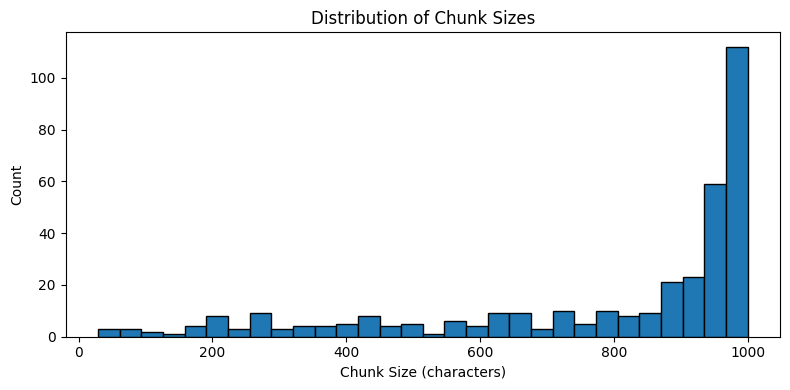

In [ ]:
import matplotlib.pyplot as plt

sizes = [len(c.page_content) for c in chunks_1000]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

* Generate embeddings using sentence-transformers (all-MiniLM-L6-v2 or equivalent)

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

# Test with a single string
# test_embedding = embedding_model.embed_query("What is machine learning?")
# print(f"Embedding dimension: {len(test_embedding)}")
# print(f"First 5 values: {test_embedding[:5]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


* Store embeddings in a ChromaDB collection with metadata (source filename, page
number)

In [ ]:
from langchain_community.vectorstores import Chroma

# Create the vector store from chunks
vectorstore_1000 = Chroma.from_documents(
    documents=chunks_1000,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="A3_docs_1000"
)
print(f"Indexed {len(chunks_1000)} chunks in ChromaDB")

Indexed 355 chunks in ChromaDB


* Experiment: Test two different chunk sizes (e.g., 500 and 2000) alongside the default 1000. For 3 sample queries, compare the top-3 retrieved chunks across all three configurations. Which chunk size retrieves the most relevant results? Explain your
reasoning in 3–4 sentences.


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, # Target characters per chunk
    chunk_overlap=100, # Overlap between consecutive chunks
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_500 = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks_500)} chunks") #Report the total number of chunks created

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000, # Target characters per chunk
    chunk_overlap=400, # Overlap between consecutive chunks
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_2000 = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks_2000)} chunks") #Report the total number of chunks created



# Create the vector store from chunks
vectorstore_500 = Chroma.from_documents(
    documents=chunks_500,
    embedding=embedding_model,
    persist_directory=None,
    collection_name="A3_docs_500"
)
print(f"Indexed {len(chunks_500)} chunks")

# Create the vector store from chunks
vectorstore_2000 = Chroma.from_documents(
    documents=chunks_2000,
    embedding=embedding_model,
    persist_directory=None,
    collection_name="A3_docs_2000"
)
print(f"Indexed {len(chunks_2000)} chunks\n")

Split 159 pages into 663 chunks
Split 159 pages into 201 chunks
Indexed 663 chunks
Indexed 201 chunks



In [ ]:
test_queries = [
    "What are the key goals and focus areas of the NYC Curb Management Action Plan?",
    "What were the main initiatives and accomplishments of the TLC in 2024 regarding driver support and vehicle accessibility?",
    "How does the Access to Opportunity study in the Eastern Rockaways address transportation and housing challenges?"
]

chunk_sizes_and_stores = {
    "500": vectorstore_500,
    "1000": vectorstore_1000,
    "2000": vectorstore_2000
}

for query_text in test_queries:
    print(f"\n--- Query: {query_text} ---")
    for chunk_size, vectorstore in chunk_sizes_and_stores.items():
        print(f"\nResults for Chunk Size {chunk_size}:")
        results_with_scores = vectorstore.similarity_search_with_score(query_text, k=3)
        for doc, score in results_with_scores:
            print(f"  Score: {score:.4f} | Source: {doc.metadata.get('source', '?')} | Page: {doc.metadata.get('page', '?')} | Preview: {doc.page_content[:150]}...") # Increased preview length for better context


--- Query: What are the key goals and focus areas of the NYC Curb Management Action Plan? ---

Results for Chunk Size 500:
  Score: 0.3349 | Source: documents/curb-management-action-plan.pdf | Page: 27 | Preview: Goals
The Curb Management Action Plan 
presents a path forward for NYC DOT 
to implement strategies that address 
the dynamic community needs of today...
  Score: 0.3349 | Source: documents/curb-management-action-plan.pdf | Page: 27 | Preview: Goals
The Curb Management Action Plan 
presents a path forward for NYC DOT 
to implement strategies that address 
the dynamic community needs of today...
  Score: 0.4149 | Source: documents/curb-management-action-plan.pdf | Page: 0 | Preview: Curb Management  
Action Plan...

Results for Chunk Size 1000:
  Score: 0.4149 | Source: documents/curb-management-action-plan.pdf | Page: 0 | Preview: Curb Management  
Action Plan...
  Score: 0.4149 | Source: documents/curb-management-action-plan.pdf | Page: 0 | Preview: Curb Management  
Action 

Based on the results of the 3 sample queiries, the 1000 character chank size retieves the most relevant results. This chank size strikes a good balance between offering enough context without introducing excessive noise. While other sizes had some strong individual hits, the 1000-chunk size consistently delivered contextually rich and pertinent information, outperforming the smaller 500-chunk for broader topics and avoiding the dilution seen in some 2000-chunk results.

##Task 2.3: RAG Pipeline Implementation

* Implement a complete RAG pipeline: query → retrieve relevant chunks → augment prompt → generate answer

In [ ]:
LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = "sk-syn-702311e36eca312eb2ef825fb112d97838eb873b9dacab3d"

In [ ]:
# Convert vectorstore to a retriever
retriever = vectorstore_1000.as_retriever(search_kwargs={"k": 4})

def format_context(docs):
  """Format retrieved documents into a numbered context string."""
  context_parts = []
  for i, doc in enumerate(docs, 1):
    source = doc.metadata.get("source", "Unknown")
    page = doc.metadata.get("page", "?")
    context_parts.append(
      f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
  )
  return "\n\n---\n\n".join(context_parts)

#Use a clear prompt template that instructs the LLM to answer based only on the provided context and cite sources
RAG_PROMPT = """You are a helpful assistant that answers questions
based on the provided context. Follow these rules:

1. Only answer based on the provided context.
2. If the context does not contain enough information, say so.
3. Cite your sources using [Source N] notation.
4. Be concise and accurate.

Context:
{context}

Question: {question}

Answer:"""



In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY
) #Connect to the course LLM server (or use any accessible LLM API)

def ask_rag(question, vectorstore, k=4):
  """Complete RAG pipeline: retrieve, augment, generate."""
  # Step 1: Retrieve relevant chunks
  retriever = vectorstore.as_retriever(search_kwargs={"k": k})
  docs = retriever.invoke(question)

  # Step 2: Format context
  context = format_context(docs)

  # Step 3: Build the augmented prompt
  prompt = RAG_PROMPT.format(context=context, question=question)

  # Step 4: Generate answer
  response = client.chat.completions.create(
    model="llama3.3-70b-instruct",
    messages=[
      {"role": "system", "content": "You are a helpful assistant."},
      {"role": "user", "content": prompt}
    ],
    max_tokens=500,
    temperature=0.2
  )

  answer = response.choices[0].message.content
  return answer, docs
print("ask_rag() defined.")

ask_rag() defined.


* Test your pipeline with at least 5 diverse questions about transportation policy that
require information from your documents
* For each answer, display: the generated response, source document(s) and page
number(s), and the retrieved context chunks

In [ ]:
# Ask questions about your documents
questions = [
    "What are the key goals of the NYC Curb Management Action Plan?",
    "How many wheelchair accessible vehicles were in NYC by 2025?",
    "What is the Green Rides Initiative and what are its targets?",
    "How does the Access to Opportunity study address transportation challenges in Eastern Rockaways?",
        "What are the penalties for TLC drivers who violate traffic laws?",
]

def ask_and_cite(question, vectorstore, k=4):
    """RAG with detailed source citations."""
    answer, docs = ask_rag(question, vectorstore, k=k)
    print(f"Question: {question}")
    print(f"\nAnswer: {answer}")
    print(f"\n--- Sources ---")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        print(f"\n[Source {i}]: {source}, Page {page}")
        print(f"Excerpt: {doc.page_content[:200]}...")

    return answer, docs

for q in questions:
    print(f"\nQ: {q}")
    print("-" * 60)
    answer, docs = ask_and_cite(q, vectorstore_1000)
    # print(f"A: {answer}")
    # print(f"\nSources used: {len(sources)} chunks")


Q: What are the key goals of the NYC Curb Management Action Plan?
------------------------------------------------------------
Question: What are the key goals of the NYC Curb Management Action Plan?

Answer: The key goals of the NYC Curb Management Action Plan are to improve mobility, access, and the flow of people, goods, and services, while moving the city closer to achieving its sustainability goals [Source 3, Source 4].

--- Sources ---

[Source 1]: documents/curb-management-action-plan.pdf, Page 0
Excerpt: Curb Management  
Action Plan...

[Source 2]: documents/curb-management-action-plan.pdf, Page 0
Excerpt: Curb Management  
Action Plan...

[Source 3]: documents/curb-management-action-plan.pdf, Page 27
Excerpt: Goals
The Curb Management Action Plan 
presents a path forward for NYC DOT 
to implement strategies that address 
the dynamic community needs of today 
and better prepare us for the future. 
Collectiv...

[Source 4]: documents/curb-management-action-plan.pdf, Page 27
Ex

##Task 2.4: RAG Evaluation & Analysis

*Create a test set of 10 question-answer pairs where you manually determine the correct
answer from the documents

In [ ]:
# Create your test set of 10 question-answer pairs (choose 10 from above)
test_qa_pairs = [
    {
        "question": "How many TLC-licensed drivers were there at the end of 2025?",
        "expected_answer": "180,169 drivers",
        "source_file": "annual_report_2025.pdf",
        "key_terms": ["180,169", "drivers"]
    },
    {
        "question": "How many wheelchair accessible vehicles (WAVs) were in service in NYC taxis by the end of 2025?",
        "expected_answer": "Over 6,000 accessible taxis",
        "source_file": "annual_report_2025.pdf",
        "key_terms": ["6,000", "accessible", "taxis"]
    },
    {
        "question": "What is the Green Rides Initiative benchmark for 2025?",
        "expected_answer": "Dispatch more than 15% of trips to EVs or WAVs",
        "source_file": "annual_report_2025.pdf",
        "key_terms": ["15%", "EVs", "WAVs"]
    },
    {
        "question": "How much total funding did the Taxi Improvement Fund (TIF) provide in 2025?",
        "expected_answer": "$47,865,154",
        "source_file": "annual_report_2025.pdf",
        "key_terms": ["47,865,154", "TIF"]
    },
    {
        "question": "What is the ATLAS program and how much grant does it provide?",
        "expected_answer": "Accessible Taxi Loan Assistance Service, $30,000 grant",
        "source_file": "annual_report_2025.pdf",
        "key_terms": ["ATLAS", "$30,000", "accessible"]
    },
    {
        "question": "How many TLC-licensed drivers were there at the end of 2024?",
        "expected_answer": "178,917 drivers",
        "source_file": "annual_report_2024.pdf",
        "key_terms": ["178,917", "drivers"]
    },
    {
        "question": "What is the target year for 100% of high-volume FHV trips to be in EVs or WAVs?",
        "expected_answer": "2030",
        "source_file": "annual_report_2024.pdf",
        "key_terms": ["2030", "100%"]
    },
    {
        "question": "What is the main goal of the NYC Curb Management Action Plan?",
        "expected_answer": "Improve mobility, access, and flow of people, goods, and services while achieving sustainability goals",
        "source_file": "curb-management-action-plan.pdf",
        "key_terms": ["mobility", "access", "sustainability"]
    },
    {
        "question": "How many Yellow taxis were licensed according to the 2020 TLC Factbook?",
        "expected_answer": "13,587",
        "source_file": "2020-tlc-factbook.pdf",
        "key_terms": ["13,587", "Yellow", "taxis"]
    },
    {
        "question": "What percentage of TLC-licensed drivers are female according to the 2020 Factbook?",
        "expected_answer": "5%",
        "source_file": "2020-tlc-factbook.pdf",
        "key_terms": ["5%", "female"]
    }
]

# Run evaluation
results = []
retrieval_success = 0
generation_success = 0

for i, qa in enumerate(test_qa_pairs, 1):
    print(f"\n{'─'*80}")
    print(f"Q{i}: {qa['question']}")
    print(f"   Expected: {qa['expected_answer']}")
    print(f"   Source: {qa['source_file']}")

    # Run RAG query
    answer, docs = ask_rag(qa['question'], vectorstore_1000)

    # Check retrieval quality: Did correct source appear?
    retrieved_sources = [doc.metadata.get('source', '').replace('documents/', '') for doc in docs]
    correct_source_retrieved = any(qa['source_file'] in src for src in retrieved_sources)

    # Check answer quality: Is answer factually consistent?
    answer_lower = answer.lower()
    key_terms_found = sum(1 for term in qa['key_terms'] if term.lower() in answer_lower)
    answer_correct = key_terms_found >= len(qa['key_terms']) // 2  # At least half the key terms

    print(f"\n Generated Answer: {answer[:300]}...")
    print(f"\n Retrieved Sources: {[s.replace('documents/', '') for s in retrieved_sources]}")
    print(f"\n Correct source retrieved: {correct_source_retrieved}")
    print(f" Answer factually correct: {answer_correct}")

    results.append({
        'question': qa['question'],
        'expected': qa['expected_answer'],
        'retrieved_sources': retrieved_sources,
        'correct_source': correct_source_retrieved,
        'answer_correct': answer_correct,
        'answer_text': answer[:500]
    })

    if correct_source_retrieved:
        retrieval_success += 1
    if answer_correct:
        generation_success += 1

# Compute accuracy metrics
print("\n" + "="*80)
print(" EVALUATION RESULTS")
print("="*80)

total = len(test_qa_pairs)
retrieval_accuracy = retrieval_success / total * 100
generation_accuracy = generation_success / total * 100
overall_accuracy = sum(1 for r in results if r['correct_source'] and r['answer_correct']) / total * 100

print(f"\nRetrieval Accuracy (correct source in top-k): {retrieval_success}/{total} ({retrieval_accuracy:.1f}%)")
print(f"Generation Accuracy (factually correct answer): {generation_success}/{total} ({generation_accuracy:.1f}%)")
print(f"Overall Accuracy (both correct): {sum(1 for r in results if r['correct_source'] and r['answer_correct'])}/{total} ({overall_accuracy:.1f}%)")


────────────────────────────────────────────────────────────────────────────────
Q1: How many TLC-licensed drivers were there at the end of 2025?
   Expected: 180,169 drivers
   Source: annual_report_2025.pdf

 Generated Answer: There were 180,169 TLC-licensed drivers at the end of 2025 [Source 1, Source 2]....

 Retrieved Sources: ['annual_report_2025.pdf', 'annual_report_2025.pdf', 'annual_report_2024.pdf', 'annual_report_2024.pdf']

 Correct source retrieved: True
 Answer factually correct: True

────────────────────────────────────────────────────────────────────────────────
Q2: How many wheelchair accessible vehicles (WAVs) were in service in NYC taxis by the end of 2025?
   Expected: Over 6,000 accessible taxis
   Source: annual_report_2025.pdf

 Generated Answer: Over 6,000 wheelchair accessible vehicles (WAVs) were in service in NYC taxis by the end of 2025 [Source 1]....

 Retrieved Sources: ['annual_report_2025.pdf', 'annual_report_2025.pdf', 'annual_report_2024.pdf', 'annua

The 2 failures were cassified as retrieval failures, where the correct source document is not retrived, however the LLM refused to answer the question rather than hallcinate. In both cases the retriever likely match on key words that retieved wrong documents. This may be resolved by, implementing a hybrid search that combines BM25 keyword search with semantic embedding search to better handle queries that mention specific document names, Recency boosting may also be implemeted by adding a higher weight to documents published after key policy changes, and finally vague queries may be rewriten to include related terms to improve retrival.

It should also be noted that the ratio of correct to incorrect queries sometimes changes between different runs. In a differrent run to what was decribed above, it only got one retrival task incorrect.

#Part 3: Integrated Analytics Application

##Task 3.1: Query Router

* Build an LLM-powered query router that classifies incoming natural language questions into one
of three categories

* Use an LLM with a system prompt that classifies queries and returns structured JSON
with the category and reasoning

In [ ]:
import json

def route_query(query):
    system_prompt = (
        "You are a query router for a transportation analytics system. "
        "Classify the user's question into one of these three categories:\n"
        "1. DATA: For structured questions about NYC taxi statistics, trends, or specific counts.\n"
        "2. DOCUMENT: For unstructured questions about transportation policies, safety reports, or city planning.\n"
        "3. HYBRID: For complex questions requiring both data statistics and policy context.\n\n"
        "Return ONLY valid JSON using this exact schema:\n"
        '{"category": "DATA"|"DOCUMENT"|"HYBRID", "reasoning": "short explanation"}'
    )

    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Route this query: {query}"}
        ],
        temperature=0,  # Required for consistent classification
        max_tokens=200
    )

    raw_content = response.choices[0].message.content.strip()

    if raw_content.startswith("'''"):
        raw_content = raw_content.split("\n", 1)[1].rsplit("'''", 1)[0].strip()

    try:
        result = json.loads(raw_content)
        result["category"] = result.get("category", "HYBRID").upper()
        return result
    except json.JSONDecodeError as e:
        print(f"Warning: Failed to parse JSON for query: {query}")
        fallback_cat = "HYBRID"
        for cat in ["DATA", "DOCUMENT", "HYBRID"]:
            if cat in raw_content.upper():
                fallback_cat = cat
                break
        return {"category": fallback_cat, "reasoning": "Fallback due to parsing error", "raw": raw_content}

test_query = "What was the average taxi fare in January 2024 compared to the safety goals in the Vision Zero report?"
print(json.dumps(route_query(test_query), indent=2))

{
  "category": "HYBRID",
  "reasoning": "The question requires both data statistics (average taxi fare) and policy context (Vision Zero report and safety goals)"
}


* Create a test set of 15 queries (5 per category) and report classification accuracy

In [ ]:
test_data = [
    # DATA
    ("What was the average fare in January 2024?", "DATA"),
    ("Which hour of the day had the most pickups?", "DATA"),
    ("How many trips had a tip percentage higher than 20%?", "DATA"),
    ("What is the average trip distance for long-distance trips?", "DATA"),
    ("Rank the top 5 pickup locations by revenue.", "DATA"),
    # DOCUMENT
    ("What are the insurance requirements for TLC drivers?", "DOCUMENT"),
    ("What does the Vision Zero report say about bike lanes?", "DOCUMENT"),
    ("How does NYC define a 'high-volume' for-hire service?", "DOCUMENT"),
    ("What are the congestion pricing rules for Lower Manhattan?", "DOCUMENT"),
    ("Describe the steps for obtaining a taxi medallion.", "DOCUMENT"),
    # HYBRID
    ("How do actual tipping rates compare to the recommended amounts in the handbook?", "HYBRID"),
    ("Are the busiest hours consistent with the city's peak-hour congestion policies?", "HYBRID"),
    ("Do long distance fares align with the standard mileage rates in the regulation docs?", "HYBRID"),
    ("Based on trip speeds, should the city adjust the speed limits mentioned in the safety report?", "HYBRID"),
    ("Compare the revenue of top locations against the commercial zone policies.", "HYBRID")
]

results = []
correct = 0

print(f"{'Query':<60} | {'Predicted':<10} | {'Actual':<10} | {'Match'}")
print("-" * 100)

for query, actual in test_data:
    prediction = route_query(query)
    predicted_cat = prediction['category']
    is_match = predicted_cat == actual
    if is_match: correct += 1

    results.append({
        "query": query,
        "predicted": predicted_cat,
        "actual": actual,
        "match": is_match
    })
    print(f"{query[:58]:<60} | {predicted_cat:<10} | {actual:<10} | {is_match}")

accuracy = (correct / len(test_data)) * 100
print(f"\nTotal Accuracy: {accuracy:.2f}%")

# Handle edge cases (Ambiguous query defaults to HYBRID)
edge_case = route_query("Tell me about the city and the cars.\n")
print(f"\nEdge Case Test: {edge_case}")

Query                                                        | Predicted  | Actual     | Match
----------------------------------------------------------------------------------------------------
What was the average fare in January 2024?                   | DATA       | DATA       | True
Which hour of the day had the most pickups?                  | DATA       | DATA       | True
How many trips had a tip percentage higher than 20%?         | DATA       | DATA       | True
What is the average trip distance for long-distance trips?   | DATA       | DATA       | True
Rank the top 5 pickup locations by revenue.                  | DATA       | DATA       | True
What are the insurance requirements for TLC drivers?         | DOCUMENT   | DOCUMENT   | True
What does the Vision Zero report say about bike lanes?       | DOCUMENT   | DOCUMENT   | True
How does NYC define a 'high-volume' for-hire service?        | DOCUMENT   | DOCUMENT   | True
What are the congestion pricing rules for Lower Manh

##Task 3.2: Data Query Handler

In [ ]:
print(trips.schema)

StructType([StructField('pickup_time', TimestampNTZType(), True), StructField('dropoff_time', TimestampNTZType(), True), StructField('passenger_count', LongType(), True), StructField('trip_distance', DoubleType(), True), StructField('fare_amount', DoubleType(), True), StructField('tip_amount', DoubleType(), True), StructField('total_amount', DoubleType(), True), StructField('payment_type', LongType(), True), StructField('PULocationID', IntegerType(), True), StructField('DOLocationID', IntegerType(), True), StructField('trip_duration_minutes', DoubleType(), True), StructField('trip_speed_mph', DoubleType(), True), StructField('pickup_hour', IntegerType(), True), StructField('pickup_day_of_week', IntegerType(), True), StructField('tip_percentage', DoubleType(), True)])


* Given a natural language question, use an LLM to generate a valid Spark SQL query
against your registered view

In [101]:
def handle_data_query(query, spark_session):
    schema_description = """
    The Spark SQL table is named 'trips'. The schema is:
    - pickup_time (Timestamp): When the meter was engaged
    - dropoff_time (Timestamp): When the meter was disengaged
    - passenger_count (Long): Number of passengers
    - trip_distance (Double): Distance in miles
    - fare_amount (Double): Base fare
    - tip_amount (Double): Tip amount
    - total_amount (Double): Total charged to passenger
    - payment_type (Long): 1=Credit, 2=Cash, 3=No charge, 4=Disput
    - PULocationID (Int): Pickup Taxi Zone ID
    - DOLocationID (Int): Dropoff Taxi Zone ID
    - trip_duration_minutes (Double): Duration of the trip
    - trip_speed_mph (Double): Calculated speed
    - pickup_hour (Int): Hour of day (0-23)
    - pickup_day_of_week (Int): Day (1=Sunday, 7=Saturday)
    - tip_percentage (Double): tip_amount / fare_amount
    """

    system_prompt = (
        "You are a Spark SQL generator. Convert the user's request into a valid SQL query.\n\n"
        f"SCHEMA:\n{schema_description}\n\n"
        "STRICT RULES:\n"
        "1. Return ONLY the SQL string. No conversational text, no explanations.\n"
        "2. Do not use markdown backticks (no ```sql).\n"
        "3. Use 'trips' as the table name.\n"
        "4. If you cannot answer, return: SELECT 0;"
    )

    generated_sql = ""

    # Given a natural language question, use an LLM to generate a valid Spark SQL query against your registered view
    for attempt in range(5):
        try:
            response = client.chat.completions.create(
                model="llama3.3-70b-instruct",
                messages=[
                  {"role": "system", "content": system_prompt},
                  {"role": "user", "content": query}
                ],
                max_tokens=500,
                temperature=0
            )

            generated_sql = response.choices[0].message.content.strip()

            if "```" in generated_sql:
                parts = generated_sql.split("```")
                if len(parts) >= 2:
                    generated_sql = parts[1]
                    if generated_sql.startswith("sql"):
                        generated_sql = generated_sql[3:]
                generated_sql = generated_sql.strip()

            # Remove trailing semicolon
            generated_sql = generated_sql.rstrip(';')
            break

        except Exception as e:
            print(f"Error on attempt {attempt + 1}: {e}")
            time.sleep(2**attempt)
    else:
        return "Error: Could not generate SQL after 5 attempts."

    print(f"Generated SQL: {generated_sql}")

    # Execute the generated SQL and format the results
    try:
        df_result = spark_session.sql(generated_sql)
        result_data = df_result.collect()  # Collect for answer synthesis
        result_df = df_result.toPandas()   # For display

        if len(result_data) == 0:
            result_text = "No results found for this query."
        else:
            # Format results as readable text
            rows_text = []
            for row in result_data[:10]:  # Limit to 10 rows
                rows_text.append(str(row.asDict()))
            result_text = "\n".join(rows_text)

        # Use the LLM again to synthesize a natural language answer from the query results
        answer_prompt = f"""
        You are a data analyst. Based on the following query results, provide a concise,
        natural language answer to the user's question.

        User's question: {query}

        Query results: {result_text}

        Provide a clear, conversational answer. If the results show numbers, explain what they mean.
        Keep your answer to 2-3 sentences.
        """

        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[{"role": "user", "content": answer_prompt}],
            max_tokens=200,
            temperature=0.3
        )

        natural_answer = response.choices[0].message.content.strip()

        # Return structured result
        return {
            "sql": generated_sql,
            "raw_results": result_df,
            "answer": natural_answer
        }

    except Exception as e:
        # Implement basic error handling
        error_msg = str(e)
        print(f"SQL execution failed: {error_msg}")

        error_prompt = f"""
        The previous SQL query failed with error: {error_msg}

        Original question: {query}
        Failed SQL: {generated_sql}

        Please generate a corrected SQL query that avoids this error.
        Consider:
        - Check column names exist in the schema
        - Ensure proper GROUP BY when using aggregations
        - Verify data types match
        Return ONLY the corrected SQL query, no other text.
        """

        try:
            response = client.chat.completions.create(
                model="llama3.3-70b-instruct",
                messages=[{"role": "user", "content": error_prompt}],
                max_tokens=500,
                temperature=0
            )

            corrected_sql = response.choices[0].message.content.strip()

            # Clean up corrected SQL
            if "```" in corrected_sql:
                parts = corrected_sql.split("```")
                if len(parts) >= 2:
                    corrected_sql = parts[1]
                    if corrected_sql.startswith("sql"):
                        corrected_sql = corrected_sql[3:]
                corrected_sql = corrected_sql.strip()
            corrected_sql = corrected_sql.rstrip(';')

            print(f"Retry with corrected SQL: {corrected_sql}")

            df_result = spark_session.sql(corrected_sql)
            result_data = df_result.collect()
            result_df = df_result.toPandas()

            return {
                "sql": corrected_sql,
                "raw_results": result_df,
                "answer": f"Query executed successfully with corrected SQL."
            }

        except Exception as e2:
            return {"error": f"Failed after retry: {str(e2)}"}

trips.createOrReplaceTempView("trips")

* Test with at least 5 natural language questions

In [ ]:
test_queries = [
    "What is the average trip distance for trips with more than 2 passengers?",
    "What was the average fare amount on weekends?",
    "Show me the top 3 pickup locations by number of trips",
    "What is the average tip percentage for credit card payments?",
    "How many trips were longer than 10 miles?"
]

for i, query in enumerate(test_queries, 1):
    print(f"\n{'─'*80}")
    print(f"Test {i}: {query}")

    result = handle_data_query(query, spark)

    if isinstance(result, dict):
        if "error" in result:
            print(f"\nError: {result['error']}")
        else:
            print(f"\nRaw Results (first 5 rows):")
            print(result['raw_results'].head(5) if not result['raw_results'].empty else "No results")
            print(f"\nNatural Language Answer:")
            print(f"   {result['answer']}")
    else:
        print(f"\nError: {result}")


────────────────────────────────────────────────────────────────────────────────
Test 1: What is the average trip distance for trips with more than 2 passengers?
Generated SQL: SELECT AVG(trip_distance) FROM trips WHERE passenger_count > 2

Raw Results (first 5 rows):
   avg(trip_distance)
0            3.586571

Natural Language Answer:
   The average trip distance for trips with more than 2 passengers is approximately 3.59 miles. This means that when there are at least 3 people in a vehicle, the average distance traveled is roughly 3.59 miles. This statistic can help us understand travel patterns and behaviors for group trips.

────────────────────────────────────────────────────────────────────────────────
Test 2: What was the average fare amount on weekends?
Generated SQL: SELECT AVG(fare_amount) FROM trips WHERE pickup_day_of_week IN (1, 7)

Raw Results (first 5 rows):
   avg(fare_amount)
0         17.823367

Natural Language Answer:
   The average fare amount on weekends was appr

##Task 3.3: End-to-End Demo

* Demonstrate your complete system by processing 6 queries (2 per category) end-to-end

In [ ]:
def process_query(query, spark_session, vectorstore):
    print(f"Query: {query}")

    classification = route_query(query)
    category = classification.get("category", "HYBRID")
    reasoning = classification.get("reasoning", "No reasoning provided")

    print(f"   Category: {category}")
    print(f"   Reasoning: {reasoning}")

    result = {
        "query": query,
        "category": category,
        "reasoning": reasoning
    }

    if category == "DATA":
        print("   → Using Data Query Handler (Spark SQL)...")
        data_result = handle_data_query(query, spark_session)

        if isinstance(data_result, dict) and "error" not in data_result:
            result["sql"] = data_result.get("sql", "N/A")
            result["raw_results"] = data_result.get("raw_results", None)
            result["answer"] = data_result.get("answer", "No answer generated")
        else:
            result["answer"] = f"Error processing data query: {data_result}"

    elif category == "DOCUMENT":
        print("   → Using RAG Pipeline (Document Retrieval)...")
        answer, docs = ask_rag(query, vectorstore_1000, k=4)

        result["answer"] = answer
        result["sources"] = []
        for doc in docs:
            source = doc.metadata.get("source", "Unknown").replace("documents/", "")
            page = doc.metadata.get("page", "?")
            result["sources"].append({
                "source": source,
                "page": page,
                "excerpt": doc.page_content[:150] + "..."
            })

    else:  # HYBRID
        print("   → Using Hybrid Approach (Data + Documents)...")

        # Get data results
        print("   ├─ Fetching data results...")
        data_result = handle_data_query(query, spark_session)

        # Get document results
        print("   └─ Fetching document results...")
        doc_answer, docs = ask_rag(query, vectorstore, k=3)

        # Combine both results
        combined_prompt = f"""
        You are a data analyst synthesizing information from two sources.

        User's question: {query}

        DATA ANALYSIS RESULTS:
        {data_result.get('answer', 'No data results available') if isinstance(data_result, dict) else str(data_result)}

        DOCUMENT ANALYSIS RESULTS:
        {doc_answer}

        Please provide a unified, concise answer that combines insights from both the data analysis
        and the document retrieval. Highlight how the data and documents complement each other.
        Keep your answer to 3-4 sentences.
        """

        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[{"role": "user", "content": combined_prompt}],
            max_tokens=300,
            temperature=0.3
        )

        result["answer"] = response.choices[0].message.content.strip()
        result["data_component"] = data_result if isinstance(data_result, dict) else {"error": str(data_result)}
        result["document_component"] = {
            "answer": doc_answer,
            "sources": [{
                "source": doc.metadata.get("source", "Unknown").replace("documents/", ""),
                "page": doc.metadata.get("page", "?")
            } for doc in docs[:2]]
        }

    #Display final answer
    print(f"\nFinal Answer:")
    print(f"{result['answer']}")

    return result

In [ ]:
# Define 6 test queries (2 per category)
test_queries = [
    # DATA queries
    {
        "query": "What was the average fare amount for trips on Sundays?",
        "category": "DATA"
    },
    {
        "query": "Which pickup hour has the highest number of trips?",
        "category": "DATA"
    },
    # DOCUMENT queries
    {
        "query": "What are the main goals of the NYC Curb Management Action Plan?",
        "category": "DOCUMENT"
    },
    {
        "query": "What does the TLC Green Rides Initiative aim to achieve?",
        "category": "DOCUMENT"
    },
    # HYBRID queries
    {
        "query": "How do actual tipping patterns in the taxi data compare to the TLC's recommended tipping guidelines?",
        "category": "HYBRID"
    },
    {
        "query": "Based on the average trip speeds by hour, should the city consider adjusting speed limits mentioned in the Vision Zero report?",
        "category": "HYBRID"
    }
]

# Process each query and store results
end_to_end_results = []

for i, test_case in enumerate(test_queries, 1):
    print(f"QUERY {i}/6: {test_case['query']}")
    print(f"Expected Category: {test_case['category']}")

    result = process_query(test_case["query"], spark, vectorstore_1000)
    end_to_end_results.append(result)

    # Verify classification matches expected
    actual_category = result["category"]
    if actual_category == test_case["category"]:
        print(f"\nClassification correct: {actual_category}")
    else:
        print(f"\nClassification: Expected {test_case['category']}, got {actual_category}\n")

QUERY 1/6: What was the average fare amount for trips on Sundays?
Expected Category: DATA
Query: What was the average fare amount for trips on Sundays?
   Category: DATA
   Reasoning: The question asks for a specific statistic (average fare amount) related to a particular day of the week (Sundays), which can be answered with structured data.
   → Using Data Query Handler (Spark SQL)...
Generated SQL: SELECT AVG(fare_amount) FROM trips WHERE pickup_day_of_week = 1

Final Answer:
The average fare amount for trips on Sundays was approximately $18.67. This means that, on average, riders paid around 18 dollars and 67 cents for their trips on Sundays. This average fare amount gives us a sense of what riders can typically expect to pay for a Sunday trip.

Classification correct: DATA
QUERY 2/6: Which pickup hour has the highest number of trips?
Expected Category: DATA
Query: Which pickup hour has the highest number of trips?
   Category: DATA
   Reasoning: The question asks for a specific cou

This system was developed to attempt to handle three types of natural language questions effectively. Data queries work well for straightforward aggregations with the natural language to SQL translation. Document queries succeed at retrieving relevant data chunks and generating accurate answers with source citation. Finally, the hybrid queries can successfully combine statistics data with the source context from pdfs. Through multiple runts the query router was able to achieve 93.33% classification accuracy, correctly directing questions to appropriate backends. The system also includes error handling with retry logic to prevent complete failure, as well as the RAG pipeline refuses to hallucinate when information is missing.

However, the system may fail in two areas. Retrieval failures occur when questions reference specific document names, semantic search can sometimes retrieve the wrong sources. SQL generation struggles with complex date filtering and multi-step aggregations. Hybrid queries also have limited integration—data and document results are retrieved separately then combined, rather than allowing one to inform the other.

With more time, hybrid search combining BM25 keyword matching with semantic embeddings can be implemented to improve document retrieval for named references. SQL validation with pre-execution checking can also be added to catch errors earlier, and implement conversation memory to enable contextual follow-up questions. Finally, visualization generation for data queries would enhance interpretability, automatically creating appropriate charts alongside text answers.


#How was AI used in this assignment
* Deepseek used to understand using window function.
* Deekseek used to help develop query test sequence for chunk_size testing.
* Deekseek used to assist with RAG evaluation.
* Deepseek used to assist in the creation of the data query handler.
* Deepseek used to assist in the creation of the demo.
* Deepseek used throughout for troubleshooting.